#📌 Extracción

In [1]:
import requests
import json
import pandas as pd
import numpy as np


In [2]:
#Extraemos la informacion y la convertimos en un data frame
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
r = requests.get(url)
data_json = r.json()

d_telecom = pd.DataFrame(data_json)

# si viene anidado, puedes usar:
# from pandas import json_normalize
# df = json_normalize(data_json, 'lista_interna', ['campos','extra'])


In [3]:
d_telecom

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [4]:
#aplicamos una normalizacion
d_telecom = pd.json_normalize(data_json)
d_telecom

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [5]:
#cambiamos los nombres de las columnas para mas facilidad
d_telecom = d_telecom.rename(columns={
    'customerID': 'customer_id',
    'Churn': 'churn',
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'senior_citizen',
    'customer.Partner': 'partner',
    'customer.Dependents': 'dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'phone_service',
    'phone.MultipleLines': 'multiple_lines',
    'internet.InternetService': 'internet_service',
    'internet.OnlineSecurity': 'online_security',
    'internet.OnlineBackup': 'online_backup',
    'internet.DeviceProtection': 'device_protection',
    'internet.TechSupport': 'tech_support',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_movies',
    'account.Contract': 'contract',
    'account.PaperlessBilling': 'paperless_billing',
    'account.PaymentMethod': 'payment_method',
    'account.Charges.Monthly': 'monthly_charges',
    'account.Charges.Total': 'total_charges'
})

In [6]:
d_telecom

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [7]:
#verificamos que las variable o columnas  tengan un correcto tipo
d_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7267 non-null   object 
 1   churn              7267 non-null   object 
 2   gender             7267 non-null   object 
 3   senior_citizen     7267 non-null   int64  
 4   partner            7267 non-null   object 
 5   dependents         7267 non-null   object 
 6   tenure             7267 non-null   int64  
 7   phone_service      7267 non-null   object 
 8   multiple_lines     7267 non-null   object 
 9   internet_service   7267 non-null   object 
 10  online_security    7267 non-null   object 
 11  online_backup      7267 non-null   object 
 12  device_protection  7267 non-null   object 
 13  tech_support       7267 non-null   object 
 14  streaming_tv       7267 non-null   object 
 15  streaming_movies   7267 non-null   object 
 16  contract           7267 

In [8]:
#total_charges esta como objet por lo que deberia cambiarse a un float64 antes veamos sus valores
d_telecom['total_charges'].value_counts(dropna=False)


,count
total_charges,
20.2,11
,11
19.75,9
19.55,9
19.9,9
...,...
1993.2,1
72.1,1
1237.85,1


In [9]:
# valores únicos ordenados, se confirma que hay 11 espacios
print(sorted(d_telecom['total_charges'].unique()))


[' ', '100.2', '100.25', '100.35', '100.4', '100.8', '100.9', '1001.2', '1001.5', '1003.05', '1004.35', '1004.5', '1004.75', '1005.7', '1006.9', '1007.8', '1007.9', '1008.55', '1008.7', '1009.25', '101.1', '101.45', '101.65', '101.9', '1010', '1011.05', '1011.5', '1011.8', '1012.4', '1013.05', '1013.2', '1013.35', '1013.6', '1014.25', '1016.7', '1017.35', '102.45', '102.5', '102.75', '1020.2', '1020.75', '1021.55', '1021.75', '1021.8', '1022.5', '1022.6', '1022.95', '1023.75', '1023.85', '1023.9', '1023.95', '1024', '1024.65', '1024.7', '1025.05', '1025.15', '1025.95', '1026.35', '1027.25', '1028.75', '1028.9', '1029.35', '1029.75', '1029.8', '103.7', '1031.1', '1031.4', '1031.7', '1032', '1032.05', '1033', '1033.9', '1033.95', '1035.5', '1035.7', '1036', '1036.75', '1037.75', '1039.45', '104.2', '104.3', '1041.8', '1042.65', '1043.3', '1043.35', '1043.4', '1043.8', '1045.25', '1046.1', '1046.2', '1046.5', '1047.7', '1048.45', '1048.85', '1049.05', '1049.6', '105.5', '105.6', '1050.5',

In [10]:
#corregimos total_charges para que sea float64
d_telecom['total_charges'] = pd.to_numeric(
    d_telecom['total_charges'], errors='coerce'
)


In [11]:
d_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7267 non-null   object 
 1   churn              7267 non-null   object 
 2   gender             7267 non-null   object 
 3   senior_citizen     7267 non-null   int64  
 4   partner            7267 non-null   object 
 5   dependents         7267 non-null   object 
 6   tenure             7267 non-null   int64  
 7   phone_service      7267 non-null   object 
 8   multiple_lines     7267 non-null   object 
 9   internet_service   7267 non-null   object 
 10  online_security    7267 non-null   object 
 11  online_backup      7267 non-null   object 
 12  device_protection  7267 non-null   object 
 13  tech_support       7267 non-null   object 
 14  streaming_tv       7267 non-null   object 
 15  streaming_movies   7267 non-null   object 
 16  contract           7267 

In [12]:
#verificamos que no haya valores na por el cambio
print(d_telecom['total_charges'].isna().sum())


11


In [13]:
# estos 11 valores son espacios en blanco asi que eliminamos
d_telecom = d_telecom.dropna(subset=['total_charges'])


In [14]:
#Verifiquemos si las columnas de categorias que valores unicos tienen nan o valores extraños
categoria_cols = d_telecom.select_dtypes(include='object').columns
for col in categoria_cols:
    print(f"\n{col}")
    print(sorted(d_telecom[col].unique()))



customer_id
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0047-ZHDTW', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-

In [15]:
#la variable churn tiene espacios en blanco
d_telecom['churn'] = d_telecom['churn'].replace('', np.nan)
d_telecom['churn'].value_counts(dropna=False)


/tmp/ipykernel_168/3824275791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d_telecom['churn'] = d_telecom['churn'].replace('', np.nan)


,count
churn,
No,5163
Yes,1869
NaN,224


In [16]:
#eliminamos los NaN para evitar errores en el futuro
d_telecom = d_telecom.dropna(subset=['churn']).reset_index(drop=True)


In [17]:
d_telecom['churn'].value_counts(dropna=False)


,count
churn,
No,5163
Yes,1869


In [18]:
#verificamos los valores nulos
d_telecom.isna().sum()

,0
customer_id,0
churn,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0


In [19]:
d_telecom

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [20]:
#datos.columns.str.lower()
d_telecom.columns

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges'],
      dtype='object')

In [21]:
#creamos la columna cuentas diarias y eliminamos excesos de decimales
d_telecom['cuentas_diarias']= d_telecom['monthly_charges'] / 30
d_telecom['cuentas_diarias'] = d_telecom['cuentas_diarias'].round(2)

d_telecom

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [22]:
categoria_cols = d_telecom.select_dtypes(include='object').columns
for col in categoria_cols:
    print(f"\n{col}")
    print(sorted(d_telecom[col].unique()))


customer_id
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-PEGZZ', '0114-

In [23]:
#estandarizacion y transformacion de Yes/no

#primero convertimos todo a minusculas
variable_yn = [ 'churn','partner','dependents', 'phone_service','paperless_billing']
for c in variable_yn:
  d_telecom[c] = d_telecom[c].str.strip().str.lower()

In [24]:
d_telecom

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,no,Female,0,yes,yes,9,yes,No,DSL,...,No,Yes,Yes,No,One year,yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,no,Male,0,no,no,9,yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,no,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,yes,Male,0,no,no,4,yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,yes,Male,1,yes,no,13,yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,yes,Female,1,yes,no,3,yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,no,Female,0,no,no,13,yes,No,DSL,...,No,Yes,No,No,One year,no,Mailed check,55.15,742.90,1.84
7028,9992-RRAMN,yes,Male,0,yes,no,22,yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,yes,Electronic check,85.10,1873.70,2.84
7029,9992-UJOEL,no,Male,0,no,no,2,yes,No,DSL,...,No,No,No,No,Month-to-month,yes,Mailed check,50.30,92.75,1.68
7030,9993-LHIEB,no,Male,0,yes,yes,67,yes,No,DSL,...,Yes,Yes,No,Yes,Two year,no,Mailed check,67.85,4627.65,2.26


In [25]:
#
map_yes_no = {'yes': 1, 'no': 0}
for c in variable_yn:
  d_telecom[c] = d_telecom[c].map(map_yes_no).astype('int64')

In [26]:
d_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   churn              7032 non-null   int64  
 2   gender             7032 non-null   object 
 3   senior_citizen     7032 non-null   int64  
 4   partner            7032 non-null   int64  
 5   dependents         7032 non-null   int64  
 6   tenure             7032 non-null   int64  
 7   phone_service      7032 non-null   int64  
 8   multiple_lines     7032 non-null   object 
 9   internet_service   7032 non-null   object 
 10  online_security    7032 non-null   object 
 11  online_backup      7032 non-null   object 
 12  device_protection  7032 non-null   object 
 13  tech_support       7032 non-null   object 
 14  streaming_tv       7032 non-null   object 
 15  streaming_movies   7032 non-null   object 
 16  contract           7032 

#📊 Carga y análisis

In [27]:
d_telecom.describe().round(2)

,churn,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,cuentas_diarias
count,7032.00,7032.00,7032.00,7032.00,7032.00,7032.0,7032.00,7032.00,7032.00,7032.00
mean,0.27,0.16,0.48,0.30,32.42,0.9,0.59,64.80,2283.30,2.16
std,0.44,0.37,0.50,0.46,24.55,0.3,0.49,30.09,2266.77,1.00
min,0.00,0.00,0.00,0.00,1.00,0.0,0.00,18.25,18.80,0.61
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,35.59,401.45,1.19
50%,0.00,0.00,0.00,0.00,29.00,1.0,1.00,70.35,1397.48,2.34
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,89.86,3794.74,2.99
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,118.75,8684.80,3.96


In [28]:
d_telecom.describe(include='object')


,customer_id,gender,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


In [76]:
import matplotlib.pyplot as plt


In [30]:
churn_counts = d_telecom['churn'].value_counts().sort_index()
churn_counts

,count
churn,
0,5163
1,1869


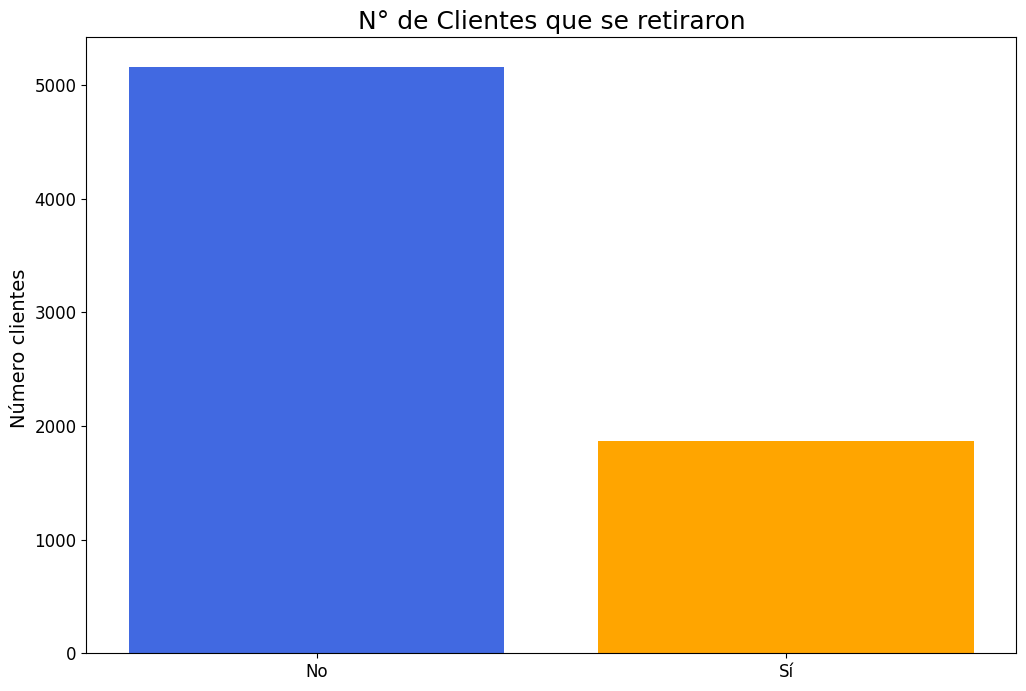

In [31]:
churn_counts = d_telecom['churn'].value_counts().sort_index()

colores = ['royalblue', 'orange']

fig, ax = plt.subplots(figsize =(12,8))
ax.bar(churn_counts.index, churn_counts.values ,color = colores )
ax.set_title('N° de Clientes que se retiraron', loc = 'center', fontsize = 18)
ax.set_xlabel('')
ax.set_ylabel('Número clientes ', fontsize = 14)

ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Sí'])

ax.xaxis.set_tick_params(labelsize = 12)
ax.yaxis.set_tick_params(labelsize = 12)

plt.show()

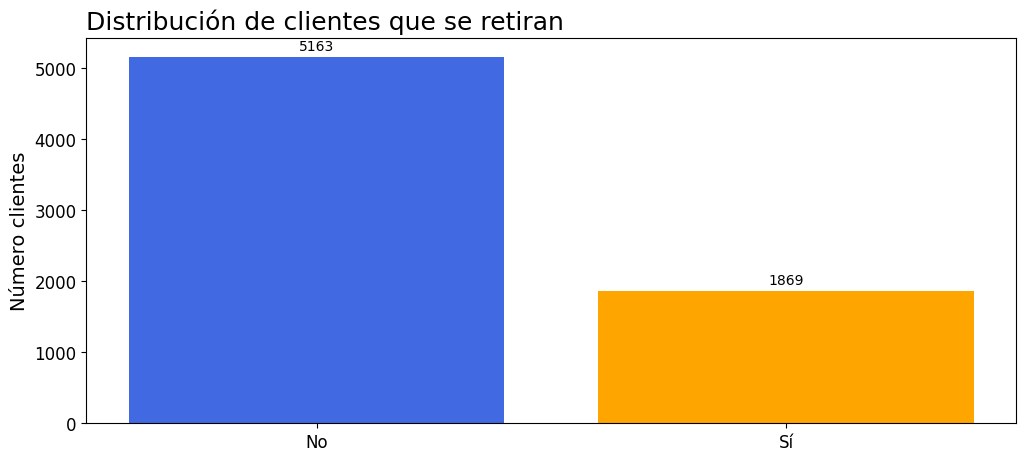

In [32]:
colores = ['royalblue', 'orange']
churn_counts = d_telecom['churn'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(churn_counts.index, churn_counts.values, color=colores)

ax.set_title('Distribución de clientes que se retiran', loc='left', fontsize=18)
ax.set_ylabel('Número clientes', fontsize=14)
ax.set_xlabel('')

ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Sí'])

# aquí Matplotlib pone las etiquetas automáticamente
ax.bar_label(bars, padding=2)  # padding = distancia sobre la barra

ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

plt.show()


In [33]:
d_telecom.columns

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'cuentas_diarias'],
      dtype='object')

In [34]:
#distribucion de evasion segun genero
tabla_gend= pd.crosstab(d_telecom['gender'], d_telecom['churn'])
print(tabla_gend)


churn      0    1
gender           
Female  2544  939
Male    2619  930


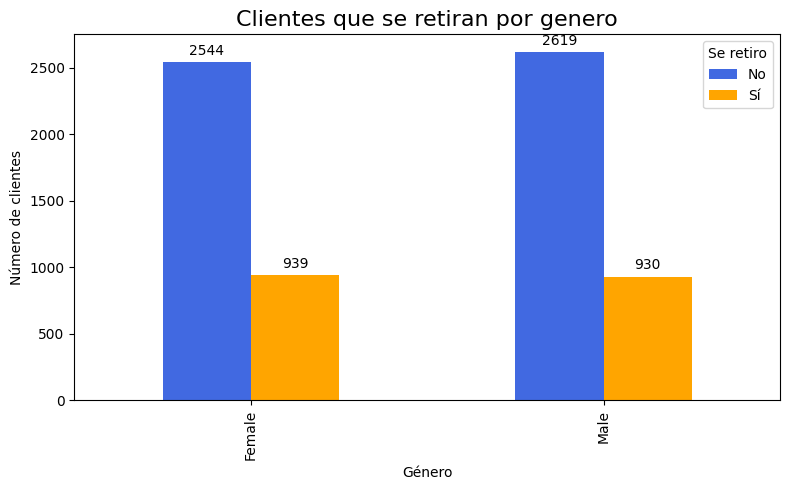

In [35]:
#hacemos la grafica
tabla_gend= pd.crosstab(d_telecom['gender'], d_telecom['churn'])
colores = ['royalblue', 'orange']  # 0 = No, 1 = Sí

fig, ax = plt.subplots(figsize=(8,5))
bars = tabla_gend.plot(kind='bar', ax=ax, color=colores)

ax.set_title('Clientes que se retiran por genero', loc='Center', fontsize=16)
ax.set_xlabel('Género')
ax.set_ylabel('Número de clientes')

ax.legend(['No', 'Sí'], title='Se retiro')

ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)

plt.tight_layout()
plt.show()


In [36]:
d_telecom.columns

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'cuentas_diarias'],
      dtype='object')

In [37]:
#distribucion de evasion segun contrato
tabla_contract= pd.crosstab(d_telecom['contract'], d_telecom['churn'])
print(tabla_contract)


churn              0     1
contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48


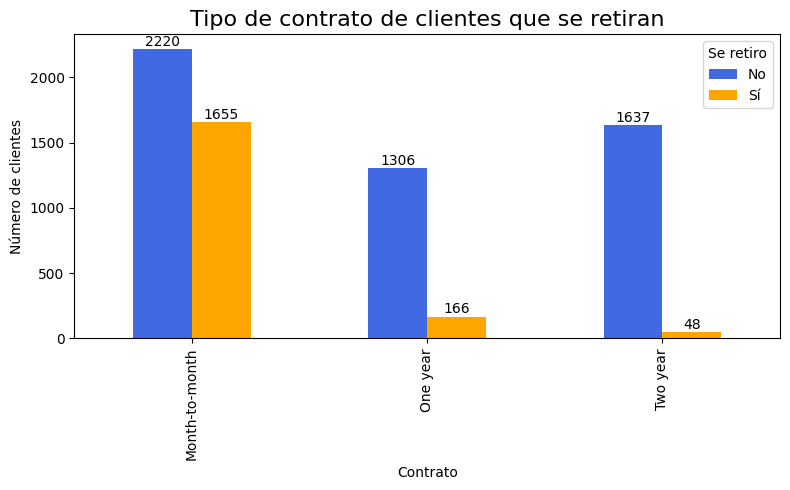

In [38]:
#hacemos la grafica
tabla_contract= pd.crosstab(d_telecom['contract'], d_telecom['churn'])

colores = ['royalblue', 'orange']  # 0 = No, 1 = Sí

fig, ax = plt.subplots(figsize=(8,5))
bars = tabla_contract.plot(kind='bar', ax=ax, color=colores)

ax.set_title('Tipo de contrato de clientes que se retiran', loc='Center', fontsize=16)
ax.set_xlabel('Contrato')
ax.set_ylabel('Número de clientes')

ax.legend(['No', 'Sí'], title='Se retiro')

ax.bar_label(ax.containers[0], padding=0.1)
ax.bar_label(ax.containers[1], padding=0.1)

plt.tight_layout()
plt.show()


In [39]:
#distribucion de evasion segun contrato
tabla_mpago= pd.crosstab(d_telecom['payment_method'], d_telecom['churn'])
print(tabla_mpago)


churn                         0     1
payment_method                       
Bank transfer (automatic)  1284   258
Credit card (automatic)    1289   232
Electronic check           1294  1071
Mailed check               1296   308


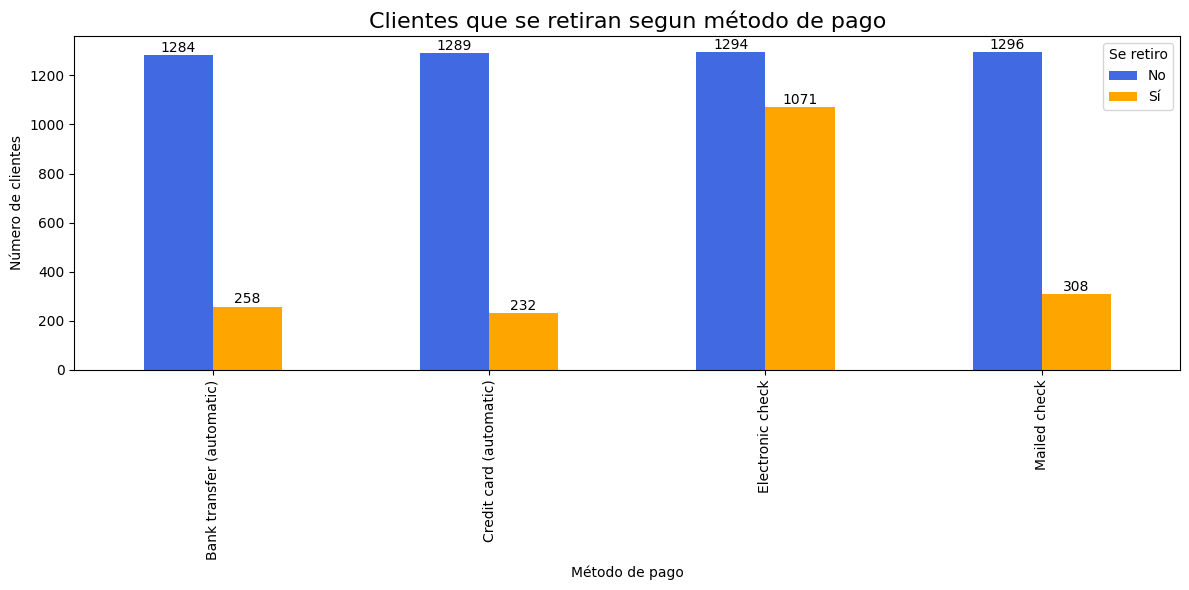

In [40]:
#hacemos la grafica
tabla_mpago= pd.crosstab(d_telecom['payment_method'], d_telecom['churn'])

colores = ['royalblue', 'orange']  # 0 = No, 1 = Sí

fig, ax = plt.subplots(figsize=(12,6))
bars = tabla_mpago.plot(kind='bar', ax=ax, color=colores)

ax.set_title('Clientes que se retiran segun método de pago', loc='Center', fontsize=16)
ax.set_xlabel('Método de pago')
ax.set_ylabel('Número de clientes')

ax.legend(['No', 'Sí'], title='Se retiro')

ax.bar_label(ax.containers[0], padding=0.1)
ax.bar_label(ax.containers[1], padding=0.1)

plt.tight_layout()
plt.show()


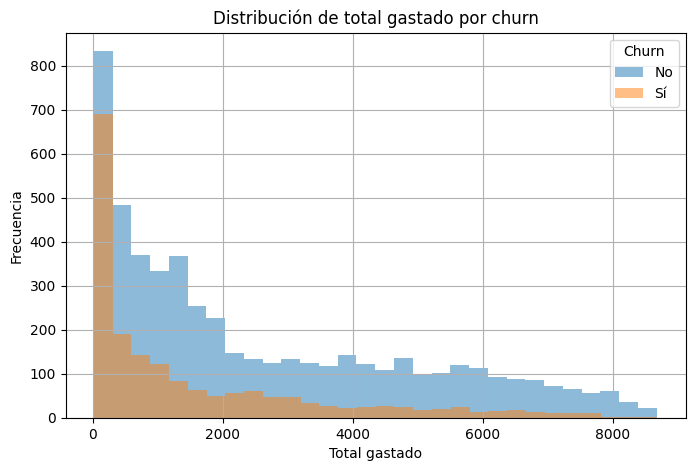

In [41]:
fig, ax = plt.subplots(figsize=(8,5))

d_telecom[d_telecom['churn'] == 0]['total_charges'].hist(
    bins=30, alpha=0.5, label='No', ax=ax
)
d_telecom[d_telecom['churn'] == 1]['total_charges'].hist(
    bins=30, alpha=0.5, label='Sí', ax=ax
)

ax.set_xlabel('Total gastado')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de total gastado por churn')
ax.legend(title='Churn')

plt.show()


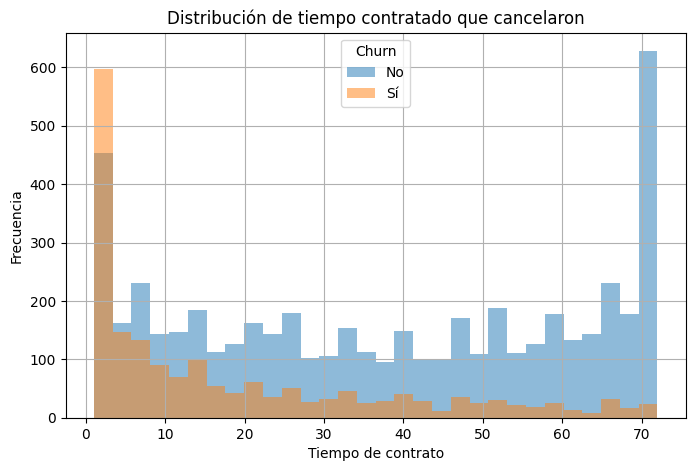

In [42]:
fig, ax = plt.subplots(figsize=(8,5))

d_telecom[d_telecom['churn'] == 0]['tenure'].hist(
    bins=30, alpha=0.5, label='No', ax=ax
)
d_telecom[d_telecom['churn'] == 1]['tenure'].hist(
    bins=30, alpha=0.5, label='Sí', ax=ax
)

ax.set_xlabel('Tiempo de contrato')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de tiempo contratado que cancelaron')
ax.legend(title='Churn')

plt.show()

In [44]:
tabla_pago = pd.crosstab(d_telecom['payment_method'], d_telecom['churn'])
tabla_pago


churn,0,1
payment_method,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [46]:
tabla_tiempo = pd.crosstab(d_telecom['total_charges'], d_telecom['churn'])
tabla_tiempo


churn,0,1
total_charges,,
18.80,1,0
18.85,1,1
18.90,1,0
19.00,1,0
19.05,1,0
...,...,...
8564.75,1,0
8594.40,1,0
8670.10,1,0


#📄Informe final

##**Introduccion**:
###El principal objetivo del análisis es evaluar la situación de cancelación de los clientes de los servicios brindados por la empresa Telecom, representada por la variable churn. Para ello se identifican, mediante gráficos y tablas, los patrones de comportamiento de variables relacionadas como el gasto total, el tipo de contratación, el tiempo de permanencia y el método de pago. Con este análisis se busca determinar cuáles de estas variables podrían estar asociadas a la decisión de un cliente de cancelar sus servicios con Telecom.


##Limpieza y tratamiento de datos

###La base de datos es obtenida mediante la Api proporcionada, para trabaja con ello primero modificamos para una correcta extraccion utilizamos el paquete Json y lo convertimos en un data frame

In [47]:
#Extraemos la informacion y la convertimos en un data frame
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
r = requests.get(url)
data_json = r.json()

d_telecom = pd.DataFrame(data_json)

### Una revision rapida de la base de datos nos sugiere normalizar la base de datos por que hay columnas que tienen informacion en cada una con llaves

In [48]:
d_telecom

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [49]:
#aplicamos una normalizacion
d_telecom = pd.json_normalize(data_json)
d_telecom

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


### Luego de la normalización identificamos que los nombres de las columnas se modificaron asi que por comodidad lo modificamos

In [50]:
#cambiamos los nombres de las columnas para mas facilidad
d_telecom = d_telecom.rename(columns={
    'customerID': 'customer_id',
    'Churn': 'churn',
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'senior_citizen',
    'customer.Partner': 'partner',
    'customer.Dependents': 'dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'phone_service',
    'phone.MultipleLines': 'multiple_lines',
    'internet.InternetService': 'internet_service',
    'internet.OnlineSecurity': 'online_security',
    'internet.OnlineBackup': 'online_backup',
    'internet.DeviceProtection': 'device_protection',
    'internet.TechSupport': 'tech_support',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_movies',
    'account.Contract': 'contract',
    'account.PaperlessBilling': 'paperless_billing',
    'account.PaymentMethod': 'payment_method',
    'account.Charges.Monthly': 'monthly_charges',
    'account.Charges.Total': 'total_charges'
})

In [51]:
d_telecom

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


###Es necesario tambien verificar si las columas o variables tiene una correcta asignacion del tipo de dato(int64, float64, object). Los gastos totales(Total_charges) estan como objet deberiamos corregirlo

In [52]:
#verificamos que las variable o columnas  tengan un correcto tipo
d_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7267 non-null   object 
 1   churn              7267 non-null   object 
 2   gender             7267 non-null   object 
 3   senior_citizen     7267 non-null   int64  
 4   partner            7267 non-null   object 
 5   dependents         7267 non-null   object 
 6   tenure             7267 non-null   int64  
 7   phone_service      7267 non-null   object 
 8   multiple_lines     7267 non-null   object 
 9   internet_service   7267 non-null   object 
 10  online_security    7267 non-null   object 
 11  online_backup      7267 non-null   object 
 12  device_protection  7267 non-null   object 
 13  tech_support       7267 non-null   object 
 14  streaming_tv       7267 non-null   object 
 15  streaming_movies   7267 non-null   object 
 16  contract           7267 

### Antes del cambio a float64 es necesario verificar los na o espacios en blanco. Que identificamos que son 11

In [53]:
#total_charges esta como objet por lo que deberia cambiarse a un float64 antes veamos sus valores
d_telecom['total_charges'].value_counts(dropna=False)

,count
total_charges,
20.2,11
,11
19.75,9
19.55,9
19.9,9
...,...
1993.2,1
72.1,1
1237.85,1


In [54]:
#corregimos total_charges para que sea float64
d_telecom['total_charges'] = pd.to_numeric(
    d_telecom['total_charges'], errors='coerce'
)

###Luego de corregirlo verificamos el cambio y los Na generados que deberian ser 11 para corregirlos

In [55]:
d_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7267 non-null   object 
 1   churn              7267 non-null   object 
 2   gender             7267 non-null   object 
 3   senior_citizen     7267 non-null   int64  
 4   partner            7267 non-null   object 
 5   dependents         7267 non-null   object 
 6   tenure             7267 non-null   int64  
 7   phone_service      7267 non-null   object 
 8   multiple_lines     7267 non-null   object 
 9   internet_service   7267 non-null   object 
 10  online_security    7267 non-null   object 
 11  online_backup      7267 non-null   object 
 12  device_protection  7267 non-null   object 
 13  tech_support       7267 non-null   object 
 14  streaming_tv       7267 non-null   object 
 15  streaming_movies   7267 non-null   object 
 16  contract           7267 

In [56]:
#verificamos que no haya valores na por el cambio
print(d_telecom['total_charges'].isna().sum())


11


In [58]:
#Eliminamos los valores Na
d_telecom = d_telecom.dropna(subset=['total_charges'])


###Ahora tambien deberiamos verificar si las variables o columnas categoricas tienen algun espacio en blanco o respuestas alteradas. Identificamos que nuestra variable de interes "Churn" o cancelación de los clientes. Como valores unicos tiene "" , "No","Yes" entonces habria que corregir

In [59]:
#Verifiquemos si las columnas de categorias que valores unicos tienen nan o valores extraños
categoria_cols = d_telecom.select_dtypes(include='object').columns
for col in categoria_cols:
    print(f"\n{col}")
    print(sorted(d_telecom[col].unique()))



customer_id
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0047-ZHDTW', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-

### Primero identifiquemos cuantos espacios en blanco hay, las transformamos en NaN para poder luego eliminarlas

In [62]:
#la variable churn tiene espacios en blanco
d_telecom['churn'] = d_telecom['churn'].replace('', np.nan)
d_telecom['churn'].value_counts(dropna=False)

,count
churn,
No,5163
Yes,1869
NaN,224


In [63]:
#eliminamos los NaN para evitar errores en el futuro
d_telecom = d_telecom.dropna(subset=['churn']).reset_index(drop=True)

In [67]:
#Verifiquemos los resultados
d_telecom['churn'].unique()

array(['No', 'Yes'], dtype=object)

In [68]:
d_telecom['churn'].value_counts(dropna=False)


,count
churn,
No,5163
Yes,1869


###Estandarizacion y transformacion de Yes/no para las variables categoricas

In [69]:
#estandarizacion y transformacion de Yes/no

#primero convertimos todo a minusculas
variable_yn = [ 'churn','partner','dependents', 'phone_service','paperless_billing']
for c in variable_yn:
  d_telecom[c] = d_telecom[c].str.strip().str.lower()

In [70]:
# cambiamos los yes y no de cada variable
map_yes_no = {'yes': 1, 'no': 0}
for c in variable_yn:
  d_telecom[c] = d_telecom[c].map(map_yes_no).astype('int64')

###Creamos la variable de gasto diario

In [71]:
#creamos la columna cuentas diarias y eliminamos excesos de decimales
d_telecom['cuentas_diarias']= d_telecom['monthly_charges'] / 30
d_telecom['cuentas_diarias'] = d_telecom['cuentas_diarias'].round(2)

d_telecom

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,0,Female,0,0,0,13,1,No,DSL,...,No,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.84
7028,9992-RRAMN,1,Male,0,1,0,22,1,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.84
7029,9992-UJOEL,0,Male,0,0,0,2,1,No,DSL,...,No,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.68
7030,9993-LHIEB,0,Male,0,1,1,67,1,No,DSL,...,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.26


##Análisis Exploratorio de Datos

###Iniciamos con un analisis descriptivo de las variables cuantitativas y cualitativas

In [74]:
#Analisis de variables cuantitativas
d_telecom.describe().round(2)

,churn,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,cuentas_diarias
count,7032.00,7032.00,7032.00,7032.00,7032.00,7032.0,7032.00,7032.00,7032.00,7032.00
mean,0.27,0.16,0.48,0.30,32.42,0.9,0.59,64.80,2283.30,2.16
std,0.44,0.37,0.50,0.46,24.55,0.3,0.49,30.09,2266.77,1.00
min,0.00,0.00,0.00,0.00,1.00,0.0,0.00,18.25,18.80,0.61
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,35.59,401.45,1.19
50%,0.00,0.00,0.00,0.00,29.00,1.0,1.00,70.35,1397.48,2.34
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,89.86,3794.74,2.99
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,118.75,8684.80,3.96


In [75]:
#analisis de variables categoricas
d_telecom.describe(include='object')


,customer_id,gender,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


### Grafiquemos la variable de cancelacion de servicios de Telecom

#### La grafica muestra que de un total de 7032 el 73%, 5163, mantiene sus servicios con Telecom pero alrededor del 27% decidieron cancelar sus servicios

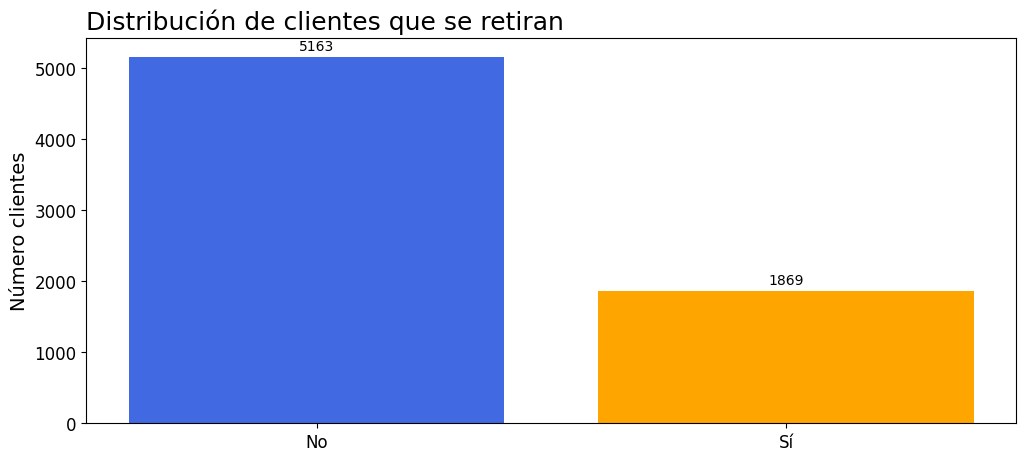

In [78]:
colores = ['royalblue', 'orange']
churn_counts = d_telecom['churn'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(churn_counts.index, churn_counts.values, color=colores)

ax.set_title('Distribución de clientes que se retiran', loc='left', fontsize=18)
ax.set_ylabel('Número clientes', fontsize=14)
ax.set_xlabel('')

ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Sí'])

# aquí Matplotlib pone las etiquetas automáticamente
ax.bar_label(bars, padding=2)  # padding = distancia sobre la barra

ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

plt.show()

### Veamos como es la distribucion de cancelacion de servicios segun el género

#### En una distribucion por genero vemos que hay una ligera diferencia entre las mujeres y varones que decidieron cancelar su producto o mantenerlo

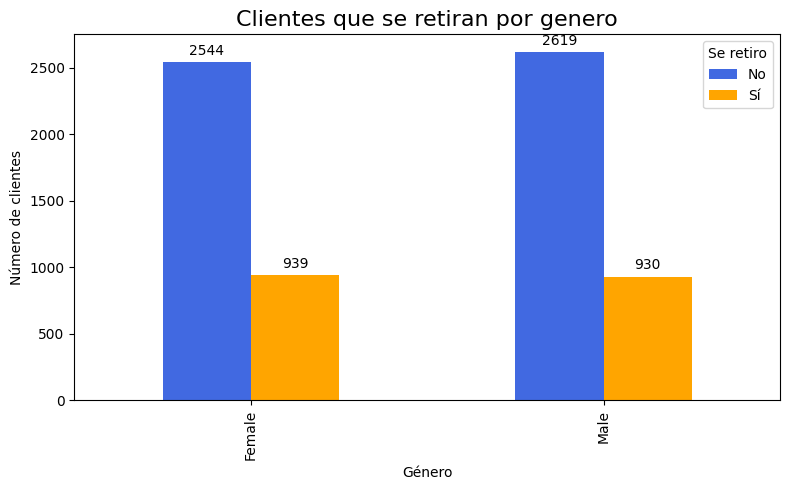

In [79]:
#hacemos la grafica
tabla_gend= pd.crosstab(d_telecom['gender'], d_telecom['churn'])
colores = ['royalblue', 'orange']  # 0 = No, 1 = Sí

fig, ax = plt.subplots(figsize=(8,5))
bars = tabla_gend.plot(kind='bar', ax=ax, color=colores)

ax.set_title('Clientes que se retiran por genero', loc='Center', fontsize=16)
ax.set_xlabel('Género')
ax.set_ylabel('Número de clientes')

ax.legend(['No', 'Sí'], title='Se retiro')

ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)

plt.tight_layout()
plt.show()

### Veamos como es la distribucion de cancelacion de servicios segun el tipo de contrato

####En la grafica podemos identificar que el tipo de contrato month to month es el que mayor ha sido cancelado y mas frecuente en comparacion a los otros metodos , seguido de oner year y two year. Habria que analizar el diseño de este para identificar las posibles causas de cancelacion

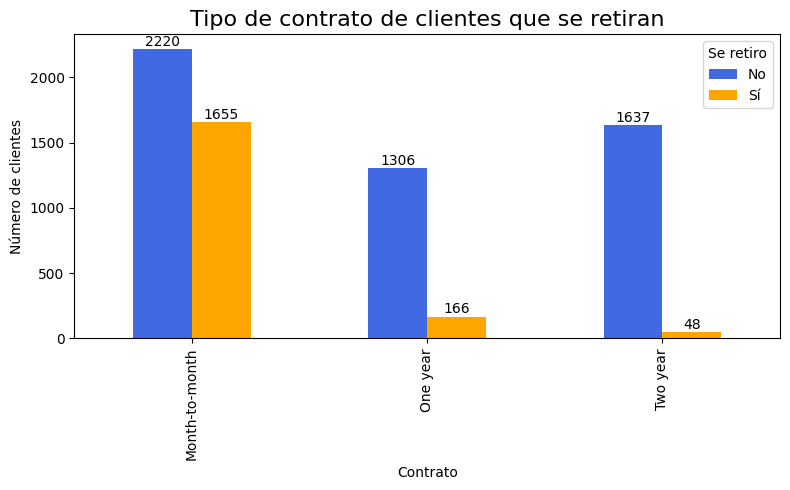

In [80]:
#hacemos la grafica
tabla_contract= pd.crosstab(d_telecom['contract'], d_telecom['churn'])

colores = ['royalblue', 'orange']  # 0 = No, 1 = Sí

fig, ax = plt.subplots(figsize=(8,5))
bars = tabla_contract.plot(kind='bar', ax=ax, color=colores)

ax.set_title('Tipo de contrato de clientes que se retiran', loc='Center', fontsize=16)
ax.set_xlabel('Contrato')
ax.set_ylabel('Número de clientes')

ax.legend(['No', 'Sí'], title='Se retiro')

ax.bar_label(ax.containers[0], padding=0.1)
ax.bar_label(ax.containers[1], padding=0.1)

plt.tight_layout()
plt.show()

### Veamos como es la distribucion de cancelacion de servicios segun el método de pago

#### En los metodos de pago tiene una ligera diferencia los que mantuvieron sus servicios, sin embargo las cancelaciones del servicio de telecom en su mayoria tenian el matodo de pago de electronic check. habria que revisar la facilidad de pago para identificar si es una causa

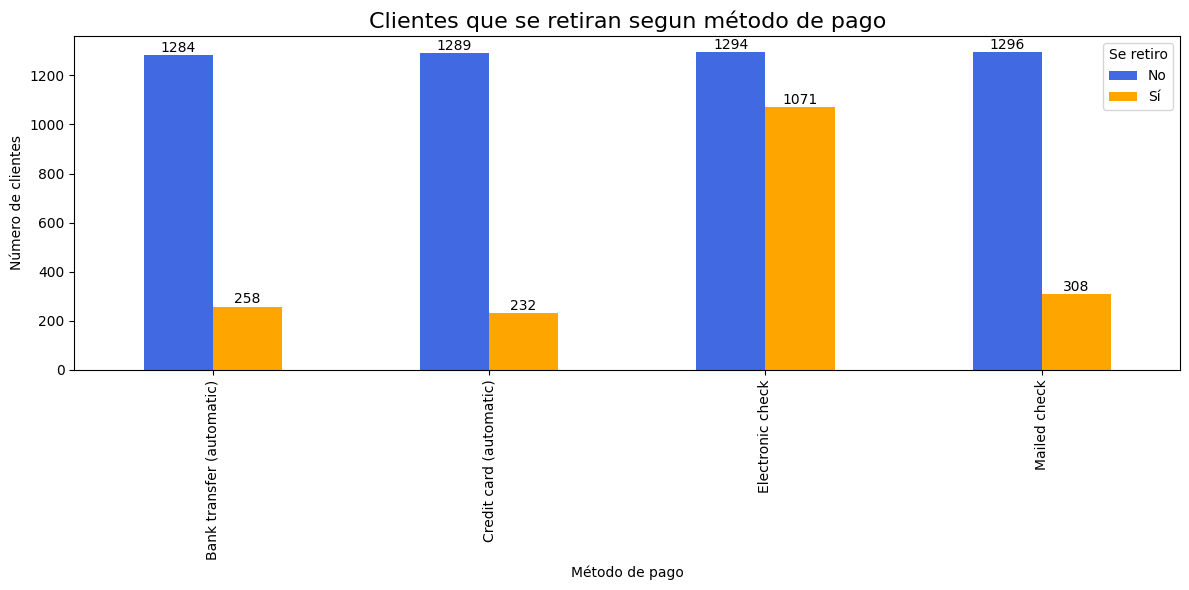

In [81]:
#hacemos la grafica
tabla_mpago= pd.crosstab(d_telecom['payment_method'], d_telecom['churn'])

colores = ['royalblue', 'orange']  # 0 = No, 1 = Sí

fig, ax = plt.subplots(figsize=(12,6))
bars = tabla_mpago.plot(kind='bar', ax=ax, color=colores)

ax.set_title('Clientes que se retiran segun método de pago', loc='Center', fontsize=16)
ax.set_xlabel('Método de pago')
ax.set_ylabel('Número de clientes')

ax.legend(['No', 'Sí'], title='Se retiro')

ax.bar_label(ax.containers[0], padding=0.1)
ax.bar_label(ax.containers[1], padding=0.1)

plt.tight_layout()
plt.show()


###Ditribucion del total gastado para la cancelacion

####La distribucion del gasto total segun si cancelo o no los servicios nos permite inferir que hay una mayor frecuencia de cancelaciones para montos menores a 2000 como gasto total.

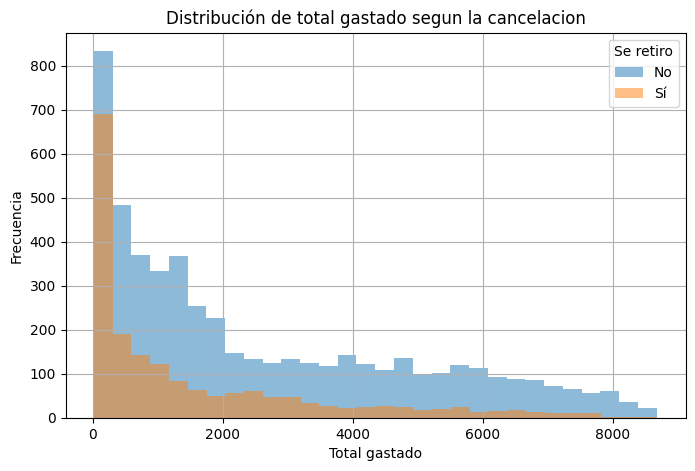

In [85]:
fig, ax = plt.subplots(figsize=(8,5))

d_telecom[d_telecom['churn'] == 0]['total_charges'].hist(
    bins=30, alpha=0.5, label='No', ax=ax
)
d_telecom[d_telecom['churn'] == 1]['total_charges'].hist(
    bins=30, alpha=0.5, label='Sí', ax=ax
)

ax.set_xlabel('Total gastado')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de total gastado segun la cancelacion')
ax.legend(title='Se retiro')

plt.show()

###Distribucion de a cancelacion segun el tiempo contratado

####El tiempo contratado nos indica que la mayor frecuencia de cancelaciones se realizan en los primeros 20 meses y a medido que pase el tiempo el numero de cancelaciones se reducen e incrementan la permanencia representado por no retiros

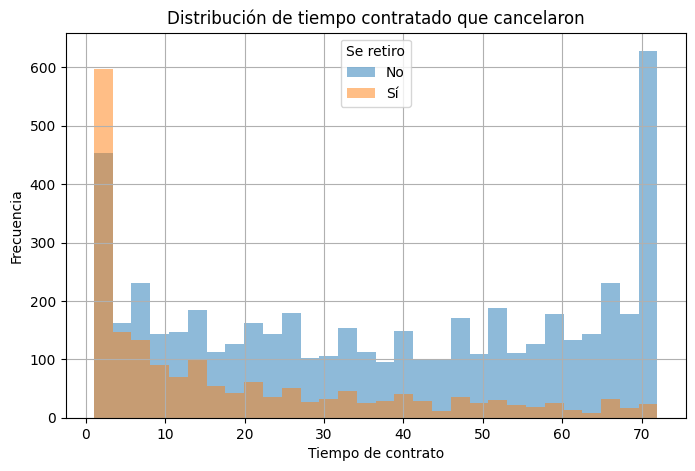

In [86]:
fig, ax = plt.subplots(figsize=(8,5))

d_telecom[d_telecom['churn'] == 0]['tenure'].hist(
    bins=30, alpha=0.5, label='No', ax=ax
)
d_telecom[d_telecom['churn'] == 1]['tenure'].hist(
    bins=30, alpha=0.5, label='Sí', ax=ax
)

ax.set_xlabel('Tiempo de contrato')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de tiempo contratado que cancelaron')
ax.legend(title='Se retiro')

plt.show()

##Conclusiones e Insights


####El número de clientes que cancelaron fue 1869, lo que equivale al 27% del total de clientes. No se observa evidencia clara de que el género esté relacionado con la cancelación del servicio, ya que las diferencias entre grupos son ligeras.

####El tipo de contrato cumple un rol protagónico en las cancelaciones de Telecom: el contrato *month‑to‑month* concentra 1655 cancelaciones, aproximadamente el 88% del total. Estos resultados sugieren que este tipo de contrato debería ser revisado para verificar la competitividad de este.

####En cuanto al método de pago, el *electronic check* es el más frecuente entre los clientes que cancelan, con 1071 casos (alrededor del 57% de las cancelaciones), mientras que los demás métodos presentan niveles de cancelación menores y relativamente similares entre sí. Esto indica la necesidad de analizar con mayor detalle este medio de pago, evaluando si existen problemas operativos o patrones por región que puedan estar asociados a una mayor cancelación.

####La distribución del gasto total sugiere que los clientes que han gastado menos de 2 000 tienden con mayor frecuencia a cancelar el servicio, mientras que, a medida que el monto acumulado aumenta, la proporción de cancelaciones disminuye. Por ello, resulta recomendable focalizar las acciones de retención en los clientes de bajo gasto, ofreciendo propuestas de valor que aumenten su uso y satisfacción con el servicio.

####El tiempo de contrato también es un factor clave: cuanto mayor es la permanencia, menor parece ser la probabilidad de cancelación. Las cancelaciones se concentran en los primeros 20 meses, por lo que se recomienda implementar programas de fidelización temprana con el fin de reducir la concentración de bajas en este periodo crítico.

:



##Recomendaciones

####Se recomienda realizar una revisión del contrato month‑to‑month, verificando si sus términos y condiciones son suficientemente competitivos o si están generando insatisfacción que derive en cancelaciones. El método de pago electronic check también debería analizarse con mayor detalle, evaluando si presenta problemas en el proceso de cobro o una disponibilidad limitada en ciertas regiones que pueda estar asociada a la baja del servicio. Asimismo, es importante ofrecer incentivos a los clientes con un gasto total inferior a 2 000 para promover su paso a planes de mayor valor y reducir la probabilidad de cancelación. Por último, se sugiere implementar acciones de fidelización focalizadas en los primeros 20 meses de contrato, periodo en el que se concentra la mayor parte de las cancelaciones en Telecom